<a href="https://colab.research.google.com/github/gg5d/DS-3025-Sp25/blob/main/bias_variance_tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bias-Variance Tradeoff Formula

The bias-variance tradeoff formula is given by:

\begin{align*}
\mathbb{E}\left[(y - \hat{f}(x;D))^2\right] & =
\mathbb{E}\left[(y - \mathbf{ \mathbb{E}_D\left[\hat{f}(x;D)\right]   + \mathbb{E}_D\left[\hat{f}(x;D)\right]} - \hat{f}(x;D))^2\right] = \\
& =
\mathbb{E}\left[ \left(y - \mathbb{E}_D\left[\hat{f}(x;D)\right]  \right)^2   \right]
 +
\mathbb{E}\left[\left(\hat{f}(x;D) -\mathbb{E}_D\left[\hat{f}(x;D)\right]\right)^2\right] = \\
& =  \text{Bias}^2  +  \text{Variance}
\end{align*}



Where:
- **$y = f(x)$**: The true value.
- **$\hat{f}(x;D)$**: The predicted value from the model with training set $D$.
- $\mathbb{E}_D\left[\hat{f}(x;D)\right]$: The average predicted value over all the training sets.
- **$\mathbb{E}[(y - \hat{f}(x;D))^2]$**: The expected mean squared error of the model with the training dataset $D$.

- **$\mathbb{E}\left[ \left(y - \mathbb{E}_D\left[\hat{f}(x;D)\right]  \right)^2   \right]$**: The squared bias, which measures the error introduced by approximating the true function $y=f(x)$ with the average of the model $\hat{f}(x;D)$.
- **$\mathbb{E}\left[\left(\hat{f}(x;D) -\mathbb{E}_D\left[\hat{f}(x;D)\right]\right)^2\right]$**: The variance, which measures the variability of the model prediction $\hat{f}(x;D)$ for different training sets $D$.


This decomposition helps in understanding how different sources of error contribute to the overall prediction error and guides the selection of models to balance bias and variance.


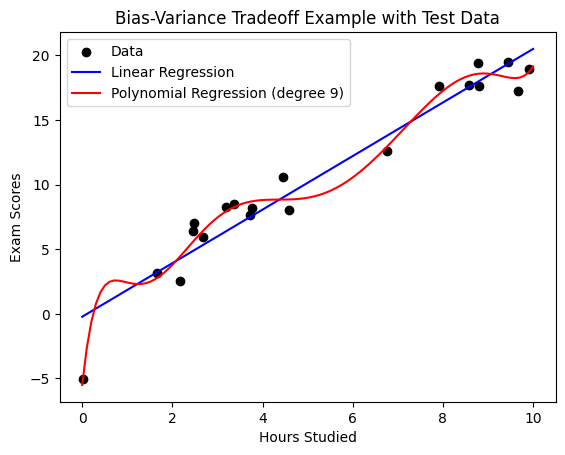

In [126]:
# prompt: now use a polynomial of degree 5

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Sample data
 np.random.seed(0)
hours_studied = np.random.rand(20, 1) * 10
exam_scores = 2 * hours_studied + 1 + np.random.randn(20, 1) * 2

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(hours_studied, exam_scores)
linear_pred = linear_model.predict(hours_studied)

# Polynomial Regression (degree 9)
poly_model = make_pipeline(PolynomialFeatures(9), LinearRegression()) # Changed degree to 9
poly_model.fit(hours_studied, exam_scores)
poly_pred = poly_model.predict(hours_studied)



# Generate a test dataset
X_test = np.linspace(0, 10, 100).reshape(-1, 1)
linear_pred_test = linear_model.predict(X_test)
poly_pred_test = poly_model.predict(X_test)


plt.scatter(hours_studied, exam_scores, color='black', label='Data')
plt.plot(X_test, linear_pred_test, color='blue', label='Linear Regression')
plt.plot(X_test, poly_pred_test, color='red', label='Polynomial Regression (degree 9)') # Changed degree to 5 in the legend
plt.xlabel('Hours Studied')
plt.ylabel('Exam Scores')
plt.legend()
plt.title('Bias-Variance Tradeoff Example with Train Data')
plt.show()


Linear Regression - Training Error: 88.5242, Test Error: 164.1090
Polynomial Regression (degree 2) - Training Error: 60.3441, Test Error: 2467.8459


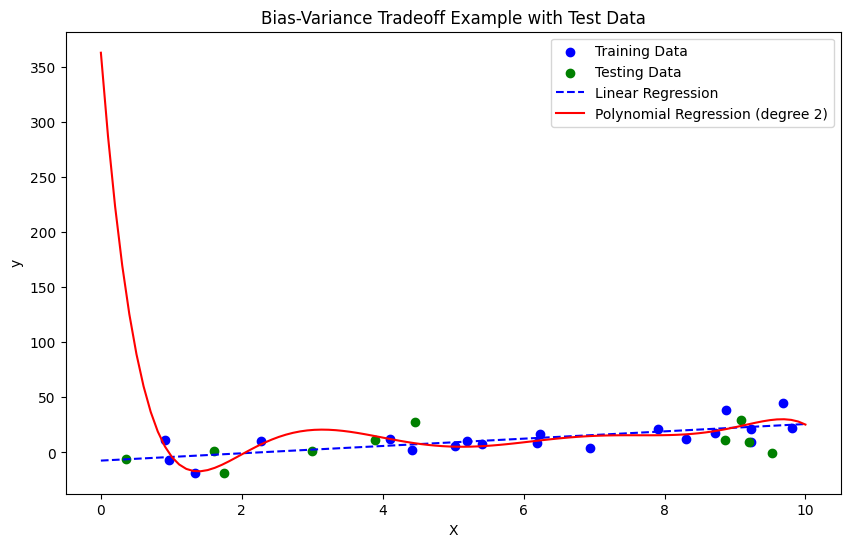

In [135]:
# repeat by using 50 point, split them 40,10 and use 40 for the training and 10 for testing,
# provide the training and the test error.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Generate 30 data points
 np.random.seed(0)
X = np.random.rand(30, 1) * 10
y = 2 * X + 1 + np.random.randn(30, 1) * 10

# Split data into training (20) and testing (10) sets
X_train = X[:20]
y_train = y[:20]
X_test = X[20:]
y_test = y[20:]

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred_train = linear_model.predict(X_train)
linear_pred_test = linear_model.predict(X_test)

# Calculate training and testing errors for linear regression
linear_train_error = mean_squared_error(y_train, linear_pred_train)
linear_test_error = mean_squared_error(y_test, linear_pred_test)

# Polynomial Regression (degree 2)
poly_model = make_pipeline(PolynomialFeatures(7), LinearRegression())
poly_model.fit(X_train, y_train)
poly_pred_train = poly_model.predict(X_train)
poly_pred_test = poly_model.predict(X_test)

# Calculate training and testing errors for polynomial regression
poly_train_error = mean_squared_error(y_train, poly_pred_train)
poly_test_error = mean_squared_error(y_test, poly_pred_test)


print(f"Linear Regression - Training Error: {linear_train_error:.4f}, Test Error: {linear_test_error:.4f}")
print(f"Polynomial Regression (degree 2) - Training Error: {poly_train_error:.4f}, Test Error: {poly_test_error:.4f}")

# Plotting with Test Data
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='green', label='Testing Data')

plt.plot(X_plot, linear_model.predict(X_plot), color='blue', linestyle='--', label='Linear Regression')
plt.plot(X_plot, poly_model.predict(X_plot), color='red', linestyle='-', label='Polynomial Regression (degree 2)')


plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Bias-Variance Tradeoff Example with Test Data')
plt.show()
